In [16]:
import scipy.io
import numpy as np
import pandas as pd

# Load MATLAB file
mat_data = scipy.io.loadmat('/Users/biyon/Documents/MySpace/Repo/pwdb_data.mat')


patient = 100

print(mat_data.keys())
print(mat_data['data'].shape)
print(mat_data['data'][0,0].dtype)
print(mat_data['data'][0,0]['waves'].shape)
print(mat_data['data'][0,0]['waves'][0,0].dtype)
for key in mat_data['data'][0,0]['waves'][0,0].dtype.fields:
    print(key, mat_data['data'][0,0]['waves'][0,0][key].shape)

print(mat_data['data'][0,0]['waves'][0,0]['U_AorticRoot'].shape)
print(mat_data['data'][0,0]['waves'][0,0]['U_AorticRoot'][0,patient].shape)

print(mat_data['data'][0,0]['haemods'][0,0].dtype)
print(mat_data['data'][0,0]['haemods'][0,patient]['age'][0,0])

dict_keys(['__header__', '__version__', '__globals__', 'data', '__function_workspace__'])
(1, 1)
[('config', 'O'), ('waves', 'O'), ('haemods', 'O'), ('pw_inds', 'O'), ('plausibility', 'O')]
(1, 1)
[('P_AorticRoot', 'O'), ('onset_times', 'O'), ('U_AorticRoot', 'O'), ('A_AorticRoot', 'O'), ('PPG_AorticRoot', 'O'), ('P_Carotid', 'O'), ('U_Carotid', 'O'), ('A_Carotid', 'O'), ('PPG_Carotid', 'O'), ('P_ThorAorta', 'O'), ('U_ThorAorta', 'O'), ('A_ThorAorta', 'O'), ('PPG_ThorAorta', 'O'), ('P_Brachial', 'O'), ('U_Brachial', 'O'), ('A_Brachial', 'O'), ('PPG_Brachial', 'O'), ('P_Radial', 'O'), ('U_Radial', 'O'), ('A_Radial', 'O'), ('PPG_Radial', 'O'), ('P_AbdAorta', 'O'), ('U_AbdAorta', 'O'), ('A_AbdAorta', 'O'), ('PPG_AbdAorta', 'O'), ('P_IliacBif', 'O'), ('U_IliacBif', 'O'), ('A_IliacBif', 'O'), ('PPG_IliacBif', 'O'), ('P_CommonIliac', 'O'), ('U_CommonIliac', 'O'), ('A_CommonIliac', 'O'), ('PPG_CommonIliac', 'O'), ('P_Femoral', 'O'), ('U_Femoral', 'O'), ('A_Femoral', 'O'), ('PPG_Femoral', 'O')

In [2]:
import scipy.io
import numpy as np
import pandas as pd

# Load MATLAB file
mat_data = scipy.io.loadmat('/Users/biyon/Documents/MySpace/Repo/pwdb_data.mat')

#range(6)
patients = [6,18,30,42,54,66,78]

for patient in patients:
    age  = mat_data['data'][0,0]['haemods'][0,patient]['age'][0,0]
    print(f"Processing patient {patient}...in age {age}")

    flowRateDate = mat_data['data'][0,0]['waves'][0,0]['U_AorticRoot'][0,patient].flatten()

    # old_min, old_max = flowRateDate.min(), flowRateDate.max()
    # new_min, new_max = 2, 25

    # # # Scale the data
    # scaledFlowRateDate = ((flowRateDate) * (new_max - new_min)) / (old_max)
    #scaledFlowRateDate = flowRateDate

    # duplicate array and concatenate to itself n times
    n = 3
    scaledFlowRateDate = np.tile(flowRateDate, n)

    fs=mat_data['data'][0,0]['waves'][0,0]['fs'][0][0]

    # Generate time column
    num_samples = scaledFlowRateDate.shape[0]
    time = np.arange(num_samples) / fs

    # Create a DataFrame
    data = pd.DataFrame({
        "Time (s)": time,
        "Value": scaledFlowRateDate
    })


    # Save to CSV with a more appropriate filename
    output_filename = f"data/Original_aortic/patient_{patient}_{n}_org.csv"
    data.to_csv(output_filename, index=False, header=False)

    print(f"Data has been saved to '{output_filename}'")

Processing patient 6...in age 25
Data has been saved to 'data/Original_aortic/patient_6_3_org.csv'
Processing patient 18...in age 35
Data has been saved to 'data/Original_aortic/patient_18_3_org.csv'
Processing patient 30...in age 45
Data has been saved to 'data/Original_aortic/patient_30_3_org.csv'
Processing patient 42...in age 55
Data has been saved to 'data/Original_aortic/patient_42_3_org.csv'
Processing patient 54...in age 65
Data has been saved to 'data/Original_aortic/patient_54_3_org.csv'
Processing patient 66...in age 75
Data has been saved to 'data/Original_aortic/patient_66_3_org.csv'
Processing patient 78...in age 25
Data has been saved to 'data/Original_aortic/patient_78_3_org.csv'


In [5]:
import scipy.io
import numpy as np
import pandas as pd

# Load MATLAB file
mat_data = scipy.io.loadmat('/Users/biyon/Documents/MySpace/Repo/pwdb_data.mat')


#read example_inlet.csv and create flowRateData array using second column and create create time array using first colomn
flowRateDate = pd.read_csv('/Users/biyon/Documents/MySpace/Repo/bloodflow-1d-model/data/example_inlet.csv', header=None).iloc[:, 1].values.flatten()
baseTime = pd.read_csv('/Users/biyon/Documents/MySpace/Repo/bloodflow-1d-model/data/example_inlet.csv', header=None).iloc[:, 0].values.flatten()






# duplicate array and concatenate to itself n times
n = 3
scaledFlowRateDate = np.tile(flowRateDate, n)

time = baseTime
for i in range(n-1):
    time = np.concatenate((time, baseTime + time[-1] - baseTime[0] +  baseTime[1] -  baseTime[0]))

print(len(time), len(scaledFlowRateDate))



# Create a DataFrame
data = pd.DataFrame({
    "Time (s)": time,
    "Value": scaledFlowRateDate
})


# Save to CSV with a more appropriate filename
output_filename = f"data/example_{n}_itt.csv"
data.to_csv(output_filename, index=False, header=False)

print(f"Data has been saved to '{output_filename}'")

438 438
Data has been saved to 'data/example_3_itt.csv'


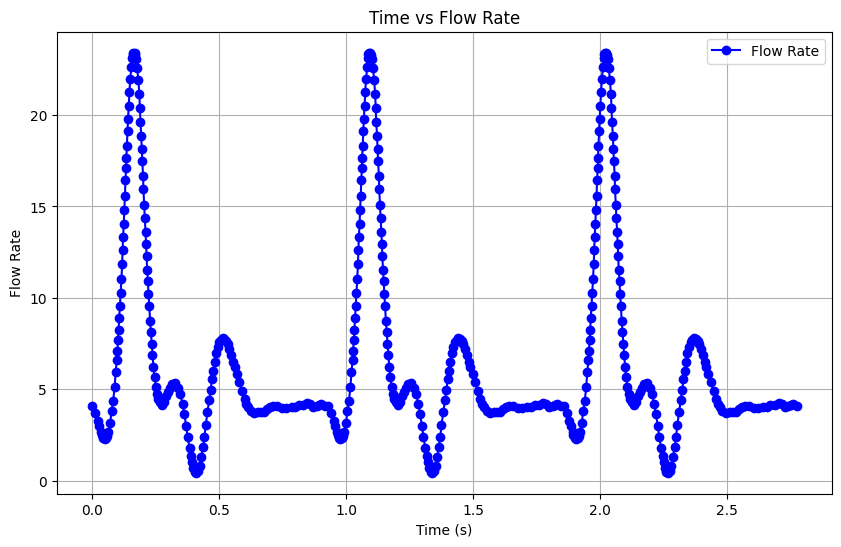

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv(output_filename, header=None, names=['Time', 'Flow Rate'])

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(df['Time'], df['Flow Rate'], marker='o', linestyle='-', color='b', label='Flow Rate')

# Adding labels and title
plt.xlabel('Time (s)')
plt.ylabel('Flow Rate')
plt.title('Time vs Flow Rate')

# Show grid
plt.grid(True)

# Show legend
plt.legend()

# Display plot
plt.show()
